# 适度涨停 + 大量跌停：复合情绪因子分组回测

用严格滞后一日的历史百分位刻画两种市场状态：

- **适度涨停**：5 日涨停占比位于自身历史约 60% 分位附近；
- **大量跌停**：5 日跌停占比越接近自身历史高位，权重越高。

复合因子将两部分得分相乘，再复用 `backtest_timeseries_factor` 做五分组回测。

In [1]:
import sys
import warnings
from bisect import bisect_left, bisect_right, insort
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# 项目根目录自动探测
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "my_utils").is_dir():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("未找到项目根目录：上级目录中缺少 my_utils/")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from my_utils.fun import read_day_data
from my_utils.rqdata import RqData
from 因子回测.alpha import backtest_timeseries_factor
from 因子回测.涨跌停情绪因子.timing_engine import (
    build_daily_sentiment_factors, prepare_stock_daily,
)

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False
warnings.filterwarnings("ignore", message="Glyph .* missing from current font")

START_DATE = date(2018, 1, 2)
END_DATE = date(2026, 7, 27)
DATA_SOURCE = "rq_stock_all_data"
WINDOW = 5
HORIZONS = (1, 3, 5, 10)
MIN_HISTORY = 252

# 复合因子参数均定义在百分位空间，避免原始涨跌停占比随市场扩容而漂移。
UP_PERCENTILE_CENTER = 0.60
UP_PERCENTILE_WIDTH = 0.20
DOWN_PERCENTILE_POWER = 2
COMPOSITE_FACTOR = "moderate_up_high_down_factor"
FACTOR_COLUMNS = [COMPOSITE_FACTOR]
FACTOR_LABELS = {COMPOSITE_FACTOR: "适度涨停 + 大量跌停"}

# ── 指数元数据：一份来源，其余自动派生 ──
BENCHMARK_META = {
    "hs300": ("000300.XSHG", "沪深300"),
    "zz500": ("000905.XSHG", "中证500"),
    "zz1000": ("000852.XSHG", "中证1000"),
    "zz2000": ("000906.XSHG", "中证2000"),
    # "cyb":  ("399006.XSHE", "创业板指"),
    # "kc50": ("000688.XSHG", "科创50"),
}
BENCHMARK_ORDER = ["hs300", "zz500", "zz1000", "zz2000"]
BENCHMARK_CODES = {key: value[0] for key, value in BENCHMARK_META.items()}
BENCHMARK_LABELS = {key: value[1] for key, value in BENCHMARK_META.items()}

In [ ]:
# ===== 1. 构建复合情绪因子（以 trading_date 为索引） =====
#
# 整体计算链路（共 5 步）：
#   ① 读取原始逐股日线数据（read_day_data）
#   ② 清洗 + 筛选股票池 + 标记涨停/跌停（prepare_stock_daily）
#   ③ 按交易日聚合 → 滚动窗口 → 六个基础情绪因子（build_daily_sentiment_factors）
#   ④ 将涨停占比 / 跌停占比映射到历史百分位空间（causal_expanding_percentile）
#   ⑤ 用钟形 × 幂函数合成最终复合因子（build_moderate_up_high_down_factor）
#
# 因子含义：
#   - "适度涨停"：涨停占比位于自身历史约 60% 分位时得分最高（钟形峰值），
#     偏离中心越远得分越低，两侧都低（涨停太少 → 市场冷清，涨停太多 → 过热）
#   - "大量跌停"：跌停占比百分位越高，得分越高（幂函数 p^2），
#     即跌停越接近历史高位越看空
#   - 复合因子 = up_score × down_score，值域 [0, 1]
#     值越高 → 涨停适中 + 跌停高 → 市场偏空


def causal_expanding_percentile(series, min_history):
    """
    计算当前值在 t-1 及更早历史中的经验百分位（严格滞后一日、防未来信息）。

    核心逻辑：
      - 维护一个有序列表 ordered_history，存放 t 日之前所有已见过的值
      - 对每个新值 current_value，用二分查找在有序历史中定位其插入位置
      - 百分位 = (left + right) / (2 * len(history))，即相同值取中间秩
      - 计算完当前值的百分位后，才把当前值插入有序历史（保证不使用当日信息）
      - 前 min_history 个有效值之前不输出百分位（预热期返回 NaN）

    参数：
      series: 待转换的原始因子序列（如涨停占比、跌停占比）
      min_history: 最少需要多少历史观测才开始输出百分位（默认 252 = 约 1 年）

    返回：
      与原序列等长的百分位序列，值域 (0, 1)，预热期为 NaN
    """
    if isinstance(min_history, bool) or not isinstance(min_history, (int, np.integer)):
        raise TypeError("min_history 必须是正整数")
    if min_history < 1:
        raise ValueError("min_history 必须是正整数")

    numeric = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan)
    percentiles = pd.Series(np.nan, index=numeric.index, dtype=float)
    ordered_history = []

    for position, current_value in enumerate(numeric.to_numpy(dtype=float)):
        if np.isfinite(current_value):
            # 只有历史样本数 >= min_history 时才计算百分位
            if len(ordered_history) >= min_history:
                left = bisect_left(ordered_history, current_value)
                right = bisect_right(ordered_history, current_value)
                # 中间秩：相同值不偏向某一侧，避免百分位虚高或虚低
                percentiles.iloc[position] = (left + right) / (2 * len(ordered_history))
            # 计算完成后才将当前值加入历史，保证因果性（不含当日信息）
            insort(ordered_history, current_value)

    return percentiles


def build_moderate_up_high_down_factor(
    up_percentile,
    down_percentile,
    up_center,
    up_width,
    down_power,
):
    """
    将涨停百分位和跌停百分位合成为单一复合因子。

    涨停部分（"适度涨停"信号）：
      - up_score = exp(-0.5 × ((up_percentile - up_center) / up_width)²)
      - 这是一个以 up_center 为中心、up_width 为宽度的钟形函数
      - 涨停占比在历史 60% 分位时得分最高 ≈ 1.0
      - 涨停占比过低（市场萎靡）或过高（情绪过热）时，得分都下降
      - 核心直觉：只有"温和偏暖"的市场环境才适合做多

    跌停部分（"大量跌停"信号）：
      - down_score = down_percentile ^ down_power
      - 跌停占比百分位越高 → 得分越高，越看空
      - down_power=2 时是平方函数，低分位区域的得分被进一步压缩，
        只有真正的高分位（历史高位）才显著得分

    复合因子 = up_score × down_score
      - 涨停适中（钟形高）+ 跌停高（幂函数高）→ 因子值高 → 市场偏空
      - 涨停极端（钟形低）或 跌停低（幂函数低）→ 因子值低 → 市场偏多
      - 值域 [0, 1]，两个子得分都在 [0, 1] 内
    """
    # 钟形函数：涨停占比在 up_center 附近得分最高
    up_score = np.exp(-0.5 * ((up_percentile - up_center) / up_width) ** 2)
    # 幂函数：跌停占比百分位越高得分越高
    down_score = down_percentile ** down_power
    return up_score * down_score


# ── 步骤①：读取原始逐股日线数据 ──
# read_day_data 从本地 parquet 文件（E:\working\stock_data）读取，
# 返回 polars DataFrame，列含 code / trading_date / close / pre_close / limit_up / limit_down 等
daily_fields = [
    "code", "trading_date", "close", "pre_close", "limit_up", "limit_down",
    "is_st", "is_suspended", "total_mv",
]
daily_raw = read_day_data(
    START_DATE, END_DATE, fields=daily_fields, file_path=DATA_SOURCE,
).sort(["code", "trading_date"])

# ── 步骤②：清洗 + 筛选股票池 + 标记涨停/跌停 ──
# prepare_stock_daily 内部完成：
#   - 算 stock_daily_ret（个股日收益）
#   - 生成全市场交易日历
#   - 沪深 A 股筛选：排除 ST、停牌、价格 ≤ 0、北交所
#   - 标记 is_limit_up / is_limit_down（收盘价 ≅ 涨停价/跌停价）
#   - 算 event_next_ret（涨停/跌停事件次日收益，排除停牌造成的跨期收益）
#   - 算 benchmark_weight（前一日总市值，用于市值加权基准）
# 返回 (prepared, calendar)：prepared 只含合格股票，calendar 是全市场交易日历
prepared_daily, trading_calendar = prepare_stock_daily(daily_raw)

# ── 步骤③：按交易日聚合 → 滚动 5 日 → 六个基础情绪因子 ──
# build_daily_sentiment_factors 内部完成：
#   1. 按 trading_date group_by，聚合每日涨停数(n_up)、跌停数(n_down)、
#      涨停次日收益总和(up_ret)、跌停次日收益总和(down_ret)、总股票数(n_stock)
#   2. 对齐到全市场日历（无事件日补 0）
#   3. 以 5 日滚动窗口计算分母（滚动最大股票数），再分项计算：
#      - limit_up_ratio: 5日总涨停数 / 5日最大合格股票数（涨停占比）
#      - limit_down_ratio: 5日总跌停数 / 5日最大合格股票数（跌停占比）
#      - net_limit_ratio: 净涨停占比 = (5日总涨停 - 5日总跌停) / 分母
#      - limit_up_down_ratio: 涨跌停比值 = 5日总涨停 / 5日总跌停（跌停=0 时返回 NaN）
#      - limit_up_next_ret: 涨停次日收益（shift(1) 防未来信息：t 日只能看到 t-1 及以前的兑现收益）
#      - limit_down_next_ret: 跌停次日收益（同上滞后一日）
# 输出：polars → pandas，以 trading_date 为索引的日频因子表
factor_data = (
    build_daily_sentiment_factors(prepared_daily, trading_calendar, window=WINDOW)
    .to_pandas()
    .assign(trading_date=lambda data: pd.to_datetime(data["trading_date"]))
    .sort_values("trading_date")
    .reset_index(drop=True)
    .set_index("trading_date")
)

# ── 步骤④：将涨停占比 / 跌停占比映射到历史百分位空间 ──
# 为什么要转百分位？
#   - 2019 年以来 A 股扩容明显（IPO 增多），原始涨停占比的绝对水平会随股票总数漂移
#   - 用历史百分位替代原始值，可以消除市场扩容的结构性影响
#   - 例如 2019 年 5% 涨停占比在当年可能算高位，但 2026 年 5% 可能只是中位水平
# 严格滞后一日：每个 t 日的百分位只使用 t-1 及更早的历史数据（causal、不含当日）
factor_data["limit_up_percentile"] = causal_expanding_percentile(
    factor_data["limit_up_ratio"], min_history=MIN_HISTORY,
)
factor_data["limit_down_percentile"] = causal_expanding_percentile(
    factor_data["limit_down_ratio"], min_history=MIN_HISTORY,
)

# ── 步骤⑤：钟形 × 幂函数 → 复合情绪因子 ──
# up_score = exp(-0.5 × ((up_percentile - 0.60) / 0.20)²)
#   → 涨停占比在历史 60% 分位时 ≈ 1.0，偏离越远得分越低
# down_score = down_percentile ^ 2
#   → 跌停占比在历史 80% 分位时得分 = 0.64，在 20% 分位时得分仅 0.04
# 两者相乘 → 复合因子：
#   - 涨停适中 + 跌停高 → 因子高（看空）
#   - 涨停极端 + 跌停低 → 因子低（看多）
factor_data[COMPOSITE_FACTOR] = build_moderate_up_high_down_factor(
    factor_data["limit_up_percentile"],
    factor_data["limit_down_percentile"],
    up_center=UP_PERCENTILE_CENTER,
    up_width=UP_PERCENTILE_WIDTH,
    down_power=DOWN_PERCENTILE_POWER,
)

# ── 数据质量校验 ──
valid_factor = factor_data[COMPOSITE_FACTOR].dropna()
assert not valid_factor.empty, "复合因子没有有效观测，请检查数据范围或预热期"
assert np.isfinite(valid_factor.to_numpy()).all(), "复合因子包含 inf/-inf"
assert valid_factor.between(0.0, 1.0).all(), "复合因子应位于 [0, 1]"

factor_data = factor_data.dropna(subset=[COMPOSITE_FACTOR]).copy()
print(f"因子数据范围: {factor_data.index.min().date()} ~ {factor_data.index.max().date()}")
print(f"有效交易日: {len(factor_data)}")
print(f"复合因子范围: {valid_factor.min():.6f} ~ {valid_factor.max():.6f}")
display(factor_data[[
    "limit_up_ratio", "limit_down_ratio",
    "limit_up_percentile", "limit_down_percentile", COMPOSITE_FACTOR,
]].tail())

In [3]:
# ===== 2. 获取多指数收益（宽表），与因子数据合并 =====
rq_returns = RqData().get_return(
    list(BENCHMARK_CODES.values()), START_DATE, END_DATE,
)
benchmark_rets = (
    rq_returns.reset_index()[["order_book_id", "date", "return"]]
    .assign(
        date=lambda data: pd.to_datetime(data["date"]),
        **{"return": lambda data: pd.to_numeric(data["return"], errors="raise").astype(float)},
    )
    .pipe(lambda data: data.loc[np.isfinite(data["return"]).to_numpy(), :])
    .pivot_table(index="date", columns="order_book_id", values="return")
    .rename(columns={value: key for key, value in BENCHMARK_CODES.items()})
    .rename_axis("trading_date")
)

# 因子 + 多指数收益 → 一张宽表（trading_date 为索引）
analysis_data = factor_data.join(benchmark_rets, how="inner")
print(f"分析数据范围: {analysis_data.index.min().date()} ~ {analysis_data.index.max().date()}")
print(f"交易日数: {len(analysis_data)}")
display(analysis_data.head())

分析数据范围: 2019-01-21 ~ 2026-07-27
交易日数: 1821


,limit_up_ratio,limit_down_ratio,net_limit_ratio,limit_up_down_ratio,limit_up_next_ret,limit_down_next_ret,limit_up_percentile,limit_down_percentile,moderate_up_high_down_factor,hs300,zz1000,zz500,zz2000
trading_date,,,,,,,,,,,,,
2019-01-21,0.05486929,0.00660730,0.04826199,8.30434783,0.01476716,-0.03666228,0.35714286,0.11706349,0.00655634,0.00551185,0.00620299,0.00593910,0.00561483
2019-01-22,0.04998564,0.00545820,0.04452743,9.15789474,0.01582724,-0.03850143,0.26482213,0.07905138,0.00153440,-0.01328441,-0.01115069,-0.01494901,-0.01368581
2019-01-23,0.05285837,0.00574548,0.04711290,9.20000000,0.02554530,-0.04263396,0.33464567,0.09055118,0.00340047,-0.00072023,0.00140541,0.00172525,-0.00013130
2019-01-24,0.05486929,0.00632002,0.04854927,8.68181818,0.02745058,-0.04645980,0.36274510,0.12156863,0.00731245,0.00564413,0.00565661,0.00521016,0.00553945
2019-01-25,0.05745475,0.00861821,0.04883654,6.66666667,0.03014744,-0.05514395,0.41015625,0.20312500,0.02629502,0.00813222,-0.00599741,-0.00454761,0.00507391


  回测进度: 1/16 (hs300, 1d)
  回测进度: 2/16 (hs300, 3d)
  回测进度: 3/16 (hs300, 5d)
  回测进度: 4/16 (hs300, 10d)
  回测进度: 5/16 (zz500, 1d)
  回测进度: 6/16 (zz500, 3d)
  回测进度: 7/16 (zz500, 5d)
  回测进度: 8/16 (zz500, 10d)
  回测进度: 9/16 (zz1000, 1d)
  回测进度: 10/16 (zz1000, 3d)
  回测进度: 11/16 (zz1000, 5d)
  回测进度: 12/16 (zz1000, 10d)
  回测进度: 13/16 (zz2000, 1d)
  回测进度: 14/16 (zz2000, 3d)
  回测进度: 15/16 (zz2000, 5d)
  回测进度: 16/16 (zz2000, 10d)

批量回测完成！共 16 条有效记录，16 组 NAV 已缓存


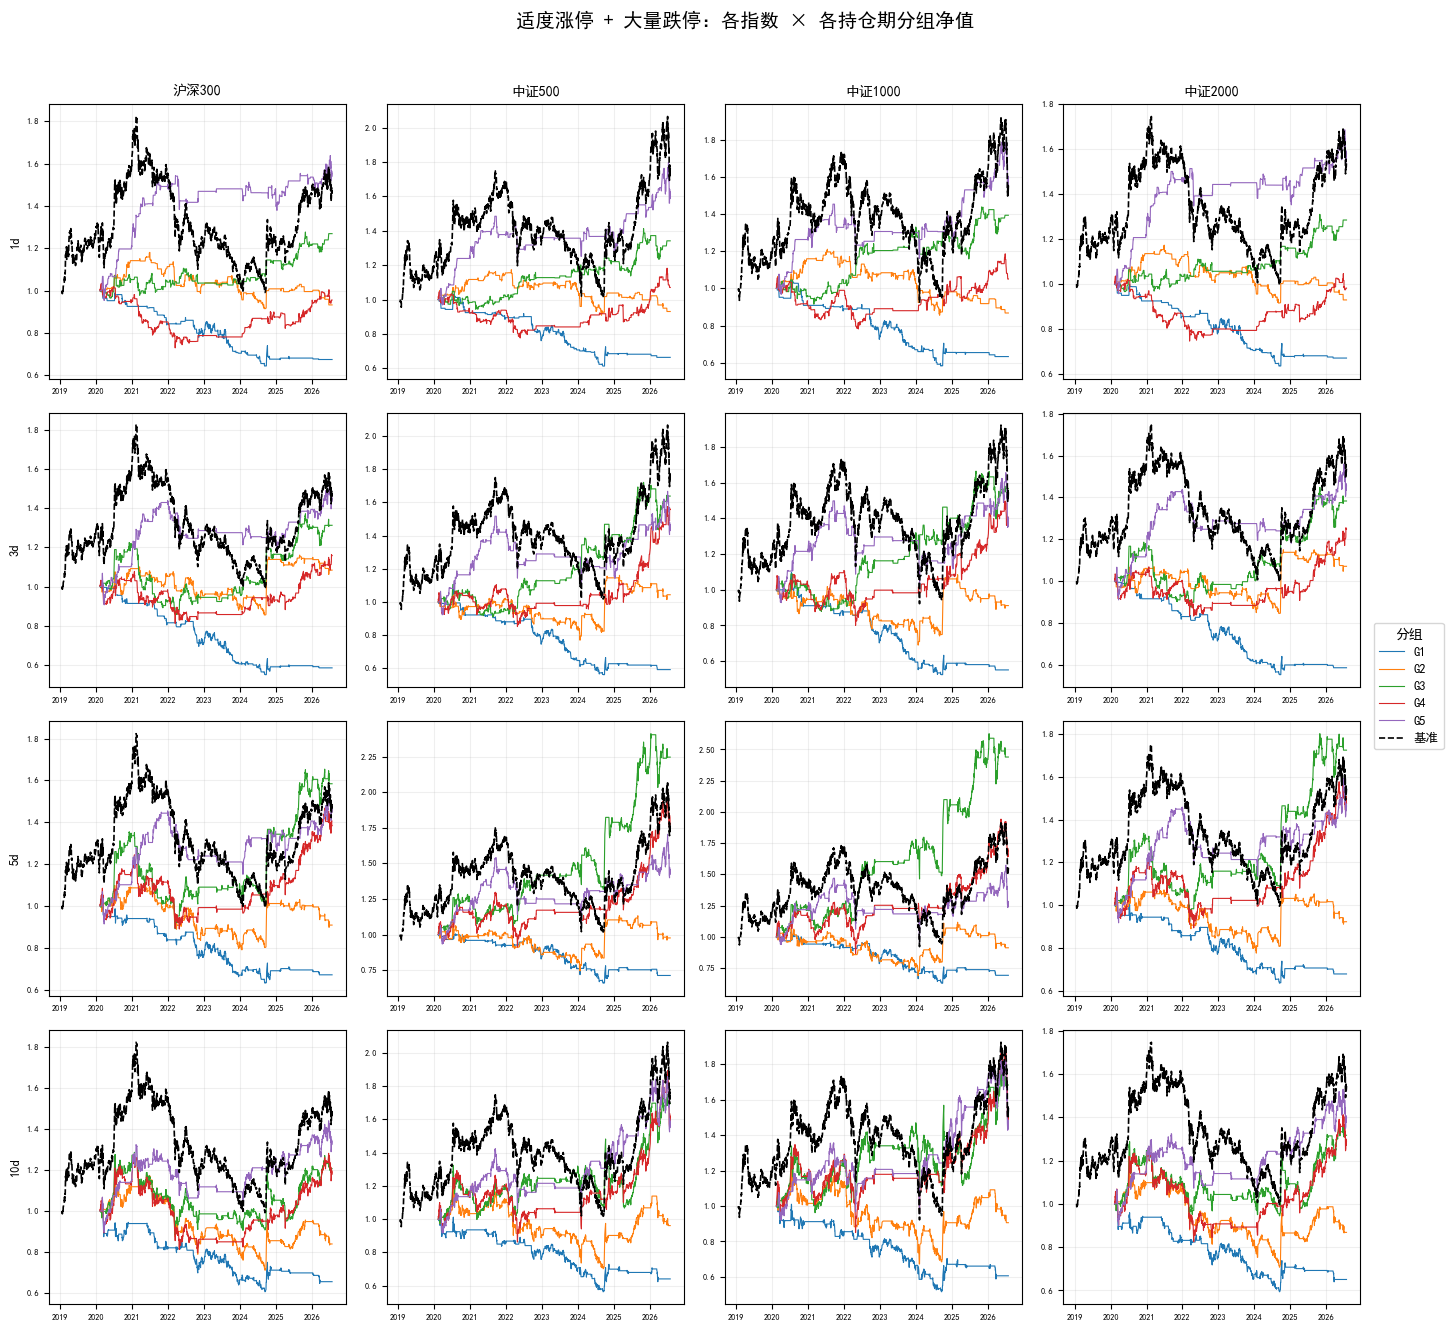

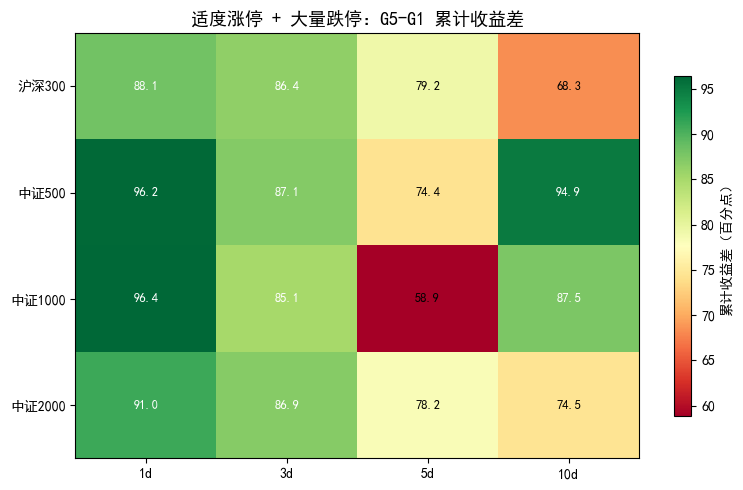

G5-G1 排序：


,factor,benchmark,horizon,G1_收益,G5_收益,G5-G1,G1_夏普,G5_夏普,基准_收益,单调递增
8,moderate_up_high_down_factor,zz1000,1,-36.63,59.78,96.41,-0.950,0.417,27.68,False
4,moderate_up_high_down_factor,zz500,1,-33.67,62.56,96.23,-1.026,0.474,43.28,False
7,moderate_up_high_down_factor,zz500,10,-35.95,58.92,94.87,-0.652,0.357,43.28,False
12,moderate_up_high_down_factor,zz2000,1,-32.86,58.10,90.96,-1.110,0.517,25.45,False
0,moderate_up_high_down_factor,hs300,1,-32.50,55.64,88.14,-1.102,0.507,20.08,False
11,moderate_up_high_down_factor,zz1000,10,-39.37,48.15,87.52,-0.601,0.274,27.68,False
5,moderate_up_high_down_factor,zz500,3,-40.75,46.39,87.15,-1.031,0.304,43.28,False
13,moderate_up_high_down_factor,zz2000,3,-41.41,45.52,86.93,-1.199,0.337,25.45,False
1,moderate_up_high_down_factor,hs300,3,-41.49,44.93,86.42,-1.212,0.339,20.08,False
9,moderate_up_high_down_factor,zz1000,3,-44.94,40.11,85.05,-0.968,0.238,27.68,False


In [4]:
# ===== 3. 批量回测、结果提取与作图 =====

def extract_metrics(result, factor, benchmark, horizon):
    """从 backtest_timeseries_factor 结果中提取首尾组和基准指标。"""
    performance = result["group_performance"]
    groups = [group for group in performance.index if group.startswith("G")]
    if len(groups) < 2:
        return None

    first_group = performance.loc["G1"]
    last_group = performance.loc[groups[-1]]
    benchmark_row = performance.loc["买入持有基准"]
    cumulative_returns = [performance.loc[group, "累计收益"] for group in groups]

    return {
        "factor": factor,
        "benchmark": benchmark,
        "horizon": horizon,
        "G1_收益": first_group["累计收益"],
        "G5_收益": last_group["累计收益"],
        "G5-G1": last_group["累计收益"] - first_group["累计收益"],
        "G1_夏普": first_group["夏普比率"],
        "G5_夏普": last_group["夏普比率"],
        "基准_收益": benchmark_row["累计收益"],
        "单调递增": all(
            cumulative_returns[index] <= cumulative_returns[index + 1]
            for index in range(len(cumulative_returns) - 1)
        ),
    }


rows = []
nav_cache = {}
total = len(FACTOR_COLUMNS) * len(BENCHMARK_ORDER) * len(HORIZONS)
count = 0

for factor in FACTOR_COLUMNS:
    for benchmark in BENCHMARK_ORDER:
        frame = analysis_data[[factor, benchmark]].dropna().copy()
        frame.columns = [factor, "ret_pct"]
        frame["ret_pct"] *= 100

        for horizon in HORIZONS:
            count += 1
            print(f"  回测进度: {count}/{total} ({benchmark}, {horizon}d)")
            result = backtest_timeseries_factor(
                frame,
                factor_col=factor,
                index_ret_col="ret_pct",
                q=5,
                hold_period=horizon,
                plot=False,
                verbose=False,
                min_history=MIN_HISTORY,
            )

            metrics = extract_metrics(result, factor, benchmark, horizon)
            if metrics is not None:
                rows.append(metrics)

            nav_cache[(factor, benchmark, horizon)] = {
                "group_nav": result["group_nav"],
                "benchmark_nav": (1 + frame["ret_pct"] / 100).cumprod(),
            }

summary = pd.DataFrame(rows)
assert len(summary) == total, f"有效回测数 {len(summary)} 与预期 {total} 不一致"
assert len(nav_cache) == total, f"NAV 缓存数 {len(nav_cache)} 与预期 {total} 不一致"
print(f"\n批量回测完成！共 {len(summary)} 条有效记录，{len(nav_cache)} 组 NAV 已缓存")


# ----- 图 A：行=持仓期，列=指数的分组净值图 -----
for factor in FACTOR_COLUMNS:
    fig, axes = plt.subplots(
        len(HORIZONS), len(BENCHMARK_ORDER),
        figsize=(3 * len(BENCHMARK_ORDER) + 3, 3 * len(HORIZONS) + 1),
        squeeze=False,
    )
    for horizon_index, horizon in enumerate(HORIZONS):
        for benchmark_index, benchmark in enumerate(BENCHMARK_ORDER):
            ax = axes[horizon_index][benchmark_index]
            cached = nav_cache[(factor, benchmark, horizon)]
            group_nav = cached["group_nav"] / cached["group_nav"].iloc[0]
            benchmark_nav = cached["benchmark_nav"] / cached["benchmark_nav"].iloc[0]

            for group in group_nav.columns:
                ax.plot(group_nav.index, group_nav[group], label=group, linewidth=0.8)
            ax.plot(
                benchmark_nav.index, benchmark_nav,
                color="black", linewidth=1.2, linestyle="--", label="基准",
            )

            if horizon_index == 0:
                ax.set_title(BENCHMARK_LABELS[benchmark], fontsize=10)
            if benchmark_index == 0:
                ax.set_ylabel(f"{horizon}d", fontsize=9)
            ax.tick_params(labelsize=6)
            ax.grid(alpha=0.2)

    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(
        handles, labels, loc="center right", fontsize=9, title="分组",
        bbox_to_anchor=(0.97, 0.5),
    )
    fig.suptitle(
        f"{FACTOR_LABELS[factor]}：各指数 × 各持仓期分组净值",
        fontsize=14, y=1.02,
    )
    fig.tight_layout(rect=[0, 0, 0.92, 1])
    plt.show()


# ----- 图 B：单因子下用“指数 × 持仓期”展示 G5-G1，避免单列热力图 -----
spread_pivot = (
    summary.pivot(index="benchmark", columns="horizon", values="G5-G1")
    .reindex(index=BENCHMARK_ORDER, columns=HORIZONS)
)
fig, ax = plt.subplots(figsize=(8, 5))
image = ax.imshow(spread_pivot.to_numpy(), cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(spread_pivot.columns)))
ax.set_xticklabels([f"{horizon}d" for horizon in spread_pivot.columns])
ax.set_yticks(range(len(spread_pivot.index)))
ax.set_yticklabels([BENCHMARK_LABELS[key] for key in spread_pivot.index])
ax.set_title("适度涨停 + 大量跌停：G5-G1 累计收益差", fontsize=13)

color_threshold = np.nanmean(np.abs(spread_pivot.to_numpy()))
for row_index in range(len(spread_pivot.index)):
    for column_index in range(len(spread_pivot.columns)):
        value = spread_pivot.iloc[row_index, column_index]
        ax.text(
            column_index, row_index, f"{value:.1f}",
            ha="center", va="center", fontsize=9,
            color="white" if abs(value) > color_threshold else "black",
        )
fig.colorbar(image, ax=ax, shrink=0.8, label="累计收益差（百分点）")
fig.tight_layout()
plt.show()


print("G5-G1 排序：")
display(
    summary.sort_values("G5-G1", ascending=False)
    .style.format({
        "G1_收益": "{:.2f}", "G5_收益": "{:.2f}", "G5-G1": "{:.2f}",
        "G1_夏普": "{:.3f}", "G5_夏普": "{:.3f}", "基准_收益": "{:.2f}",
    })
    .background_gradient(cmap="RdYlGn", subset=["G5-G1"])
)